# Graphicalizing Aesop's Fables

This notebook downloads the public-domain Project Gutenberg text for [Æsop's Fables #53103](https://www.gutenberg.org/ebooks/53103), splits it into tale-sized documents, and sends those documents through the ontology-guided semantic pipeline.

The notebook uses the package's default OpenAI `gpt-4.1-mini` client. Set `OPENAI_API_KEY` in the environment before running the model cell. The key is read by the OpenAI SDK and is never stored in this notebook.

In [ ]:
%config InlineBackend.figure_format = 'retina'

%load_ext autoreload
%autoreload 2

from pathlib import Path
from IPython.display import display

from semantic_graphicalizer import SemanticGraphicalizer, load_aesop_fables

ROOT = Path.cwd()
if not (ROOT / 'configs').exists():
    ROOT = ROOT.parent

stories = load_aesop_fables(limit=1, cache_dir=ROOT / 'data' / 'raw', select_at_random=True, rand_seed=None)
[(story.splitlines()[0], len(story)) for story in stories]

[('THE WOLF AND THE LAMB', 817)]

## OpenAI model

The transformer creates the default `OpenAIModelClient` when `model` is omitted. It uses `gpt-4.1-mini` through the Responses API and reads `OPENAI_API_KEY` from the environment.

In [2]:
from textwrap import wrap

graphicalizer = SemanticGraphicalizer(
    ontology=ROOT / 'configs' / 'ontologies' / 'aesop.yaml',
    prompts=ROOT / 'configs' / 'prompts' / 'aesop.yaml',
)

graphicalizer.fit(stories)
traces = []

for index, story in enumerate(stories, start=1):
    trace = graphicalizer.transform_with_trace([story])[0]
    traces.append(trace)
    title = story.splitlines()[0]
    print(f"\nDocument {index}/{len(stories)}: {title}")
    print("\n".join(wrap(story, width=80)))
    print(f"ID: {trace.document_id}")
    print(f"Entities: {len(trace.entities)} | Relations: {len(trace.relations)} | "
          f"Nodes: {trace.graph.number_of_nodes()} | Edges: {trace.graph.number_of_edges()}")
    print("-" * 80)
    for relation in trace.relations:
        arguments = ", ".join(f"{argument.role}={argument.entity_id}" for argument in relation.arguments)
        print(f"- {relation.type}[{relation.relation}]({arguments})")
    print("\nGraph:")
    display(graphicalizer.display(trace.graph, mode="text"))
    print("=" * 80)


[SemanticGraphicalizer] ready: model=OpenAIModelClient, ontology=aesop-narrative, domain=aesop-narrative
[document-c9dc96ffcafc] segment: 1 -> 1 | 0.2 ms | input_chars=817, chunk_chars=817
[document-c9dc96ffcafc chunk-0] summarize: 1 -> 1 | 5105.7 ms
[document-c9dc96ffcafc chunk-0] normalize: 1 -> 1 | 2557.8 ms
[document-c9dc96ffcafc chunk-0] decompose: 1 -> 13 | 8739.0 ms
[document-c9dc96ffcafc chunk-0] extract: 13 -> 23 | 16342.6 ms
[document-c9dc96ffcafc] resolve: 23 -> 0 | 1144.0 ms
[document-c9dc96ffcafc] integrate: 11 -> 22 | 0.6 ms | nodes=23, edges=22
[document-c9dc96ffcafc] total: 1 -> 1 | 33890.4 ms | chunks=1, entities=12, relations=11, nodes=23, edges=22

Document 1/1: THE WOLF AND THE LAMB
THE WOLF AND THE LAMB   [Illustration: The Wolf and the Lamb]  [Illustration]
As a Wolf was lapping at the head of a running brook, he spied a stray Lamb
paddling, at some distance down the stream. Having made up his mind to make his
dinner off her, he bethought himself how he might begi

animal: Wolf
    performs: action: drinking water
    interacts_with: animal: Lamb
    wants: goal: making the Lamb his dinner
    performs: action: starting a quarrel by accusing the Lamb of muddying the water
    performs: action: falsely accusing the Lamb of having called him ill names a year ago
    performs: action: dismissing the Lamb's explanation and blaming the Lamb's father or relations
    performs: action: seizing and tearing the Lamb to pieces
    teaches: moral: about the abuse of power and the unjust treatment of the innocent
animal: Lamb
    performs: action: responding humbly that she could not have disturbed the water
    performs: action: replied, trembling, that she was not yet born a year ago
action: drinking water
    located_in: place: brook

In [3]:
graphicalizer.display(
    traces[0].graph,
    mode="dynamic",
    layout="force",
    show_derived_links=True,
    show_source=True,
    max_width=34,
    width=1200,
    height=760,
    charge_strength=-10,
    link_distance=150,
    component_spacing=100,
    component_strength=0.3,
    parallel_edge_spacing=320
)

## Convert to AbstractGraph and visualize

The AbstractGraph display shows the reified base graph and its interpretation graph, including their mapping. Each reified base node maps to its own interpretation node, labeled by entity type; document and chunk identifiers remain in metadata. The layout uses undirected Kamada–Kawai distances by default while drawing the original directed edges.

<Axes: >

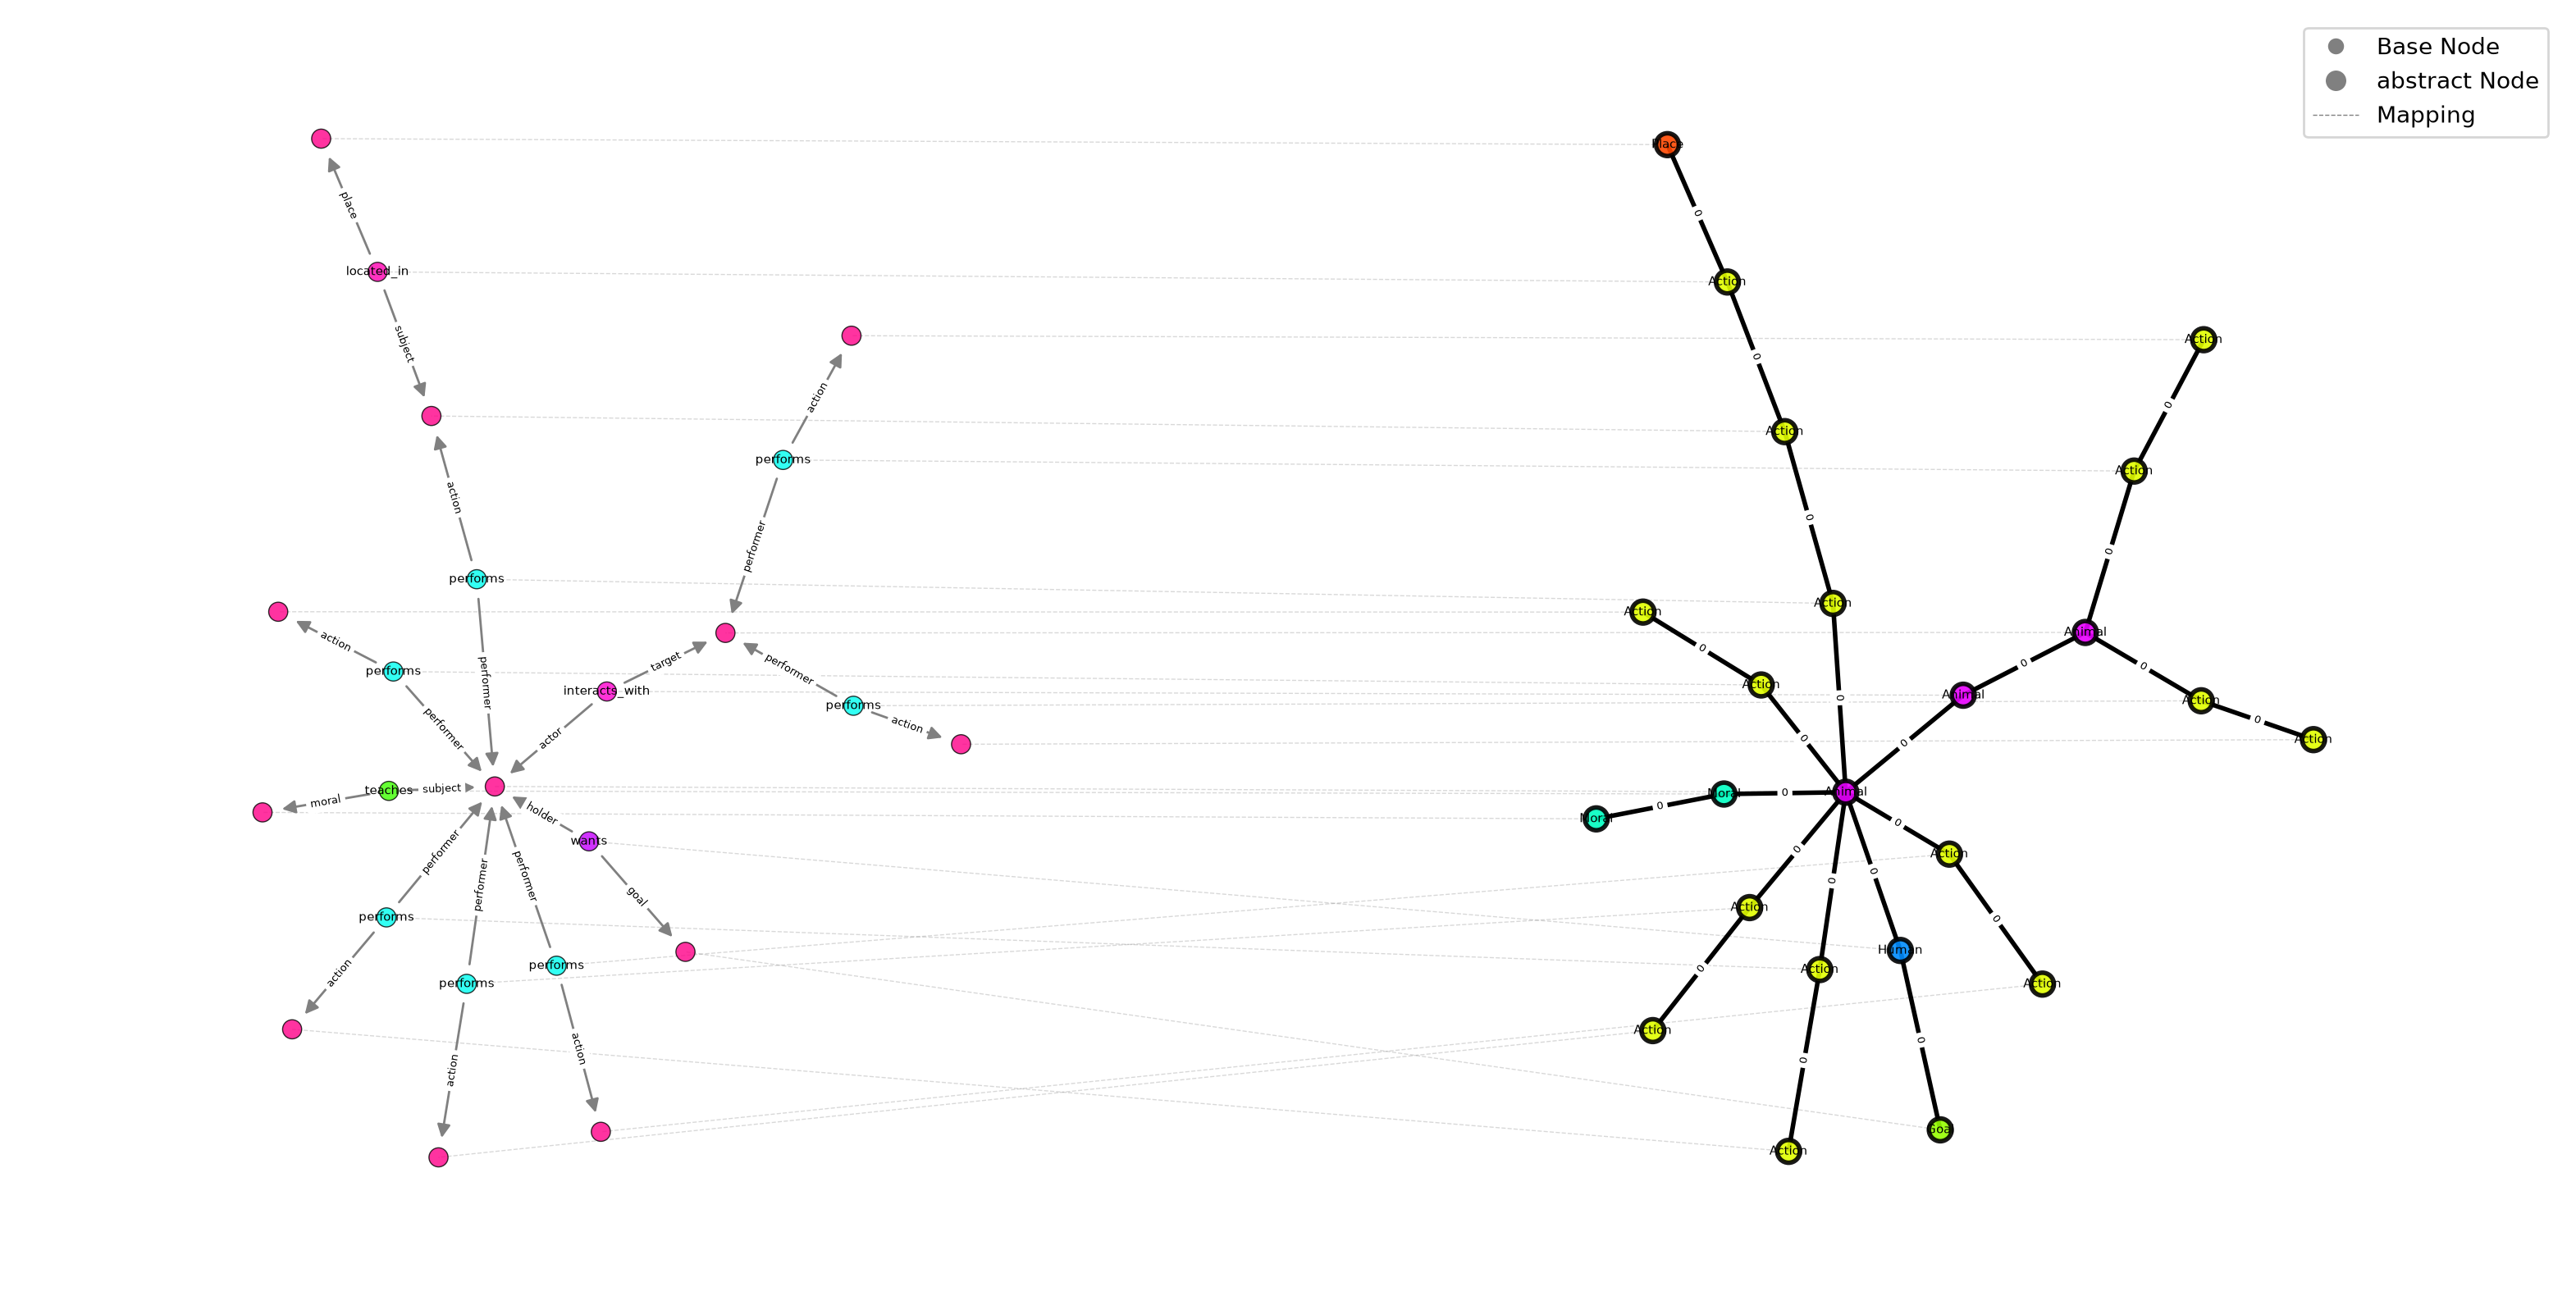

In [8]:
from abstractgraph import display as display_abstract_graph

abstract_graph = graphicalizer.to_abstract_graph(
    traces[0],
    interpretation_mode="per_entity",
    preserve_direction=True,
    embed_nodes=True,
    parallel_edge_policy="first",
)

from abstractgraph.operators import *
abstract_graph = intersection_edges(abstract_graph, accept_connection_by_edge=True)
display_abstract_graph(
    abstract_graph,
    size=(20, 10),
    show_legend=True,
    node_labels=True,
    node_label_attr="label",
    node_label_font_size=5.5,
    edge_labels=True,
    edge_label_font_size=4.5,
    undirected_layout=True,
)